# Окружение

In [5]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import os
import matplotlib.pyplot as plt
import rasterio
from rasterstats import zonal_stats
import pandas as pd
import osmnx as ox

это я добавил в своей ветке tikhon

# Загрузка полигонов районов и всей РТ

In [6]:
# 1. ЗАГРУЗКА ГРАНИЦ ИЗ ФАЙЛА
file_path = 'tatarstan_2.geojson'

if not os.path.exists(file_path):
    print(f"Файл {file_path} не найден! Проверь имя файла в папке.")
else:
    # Загружаем районы и переводим в метрическую проекцию (метры)
    districts = gpd.read_file(file_path)
    districts = districts.to_crs(epsg=32639)
    
    # Пытаемся найти колонку с названиями районов (name, NAME, name_ru и т.д.)
    possible_cols = [c for c in districts.columns if 'name' in c.lower()]
    if possible_cols:
        name_col = possible_cols[0]
        districts = districts.rename(columns={name_col: 'name'})
        print(f"Нашел колонку с названиями: '{name_col}'. Переименовал в 'name'.")
    else:
        # Если не нашли, выводим ошибку, чтобы ты посмотрел глазами
        print("Ошибка: не нашел колонку с названиями. Доступные колонки:", list(districts.columns))
        # На всякий случай создаем временное имя из индекса, чтобы код не упал
        districts['name'] = "District_" + districts.index.astype(str)

    # 2. ГЕНЕРАЦИЯ СЕТКИ 1x1 КМ
    print("Генерирую сетку...")
    xmin, ymin, xmax, ymax = districts.total_bounds
    res = 1000  # 1 км в метрах

    x_coords = np.arange(xmin, xmax, res)
    y_coords = np.arange(ymin, ymax, res)

    polygons = []
    for x in x_coords:
        for y in y_coords:
            polygons.append(Polygon([(x, y), (x + res, y), (x + res, y + res), (x, y + res)]))

    grid = gpd.GeoDataFrame({'geometry': polygons}, crs=districts.crs)

    # 3. ПРИВЯЗКА К РАЙОНАМ (SPATIAL JOIN)
    print("Привязываю ячейки к районам (это может занять 10-20 секунд)...")
    # Используем центроиды для точности и скорости
    grid['centroid'] = grid.geometry.centroid
    
    # Сопоставляем ячейки с районами
    grid_with_districts = gpd.sjoin(
        grid.set_geometry('centroid'), 
        districts[['name', 'geometry']], 
        how='inner', 
        predicate='within'
    )

    # Возвращаем ячейкам их квадратную форму и удаляем лишнее
    grid_with_districts = grid_with_districts.set_geometry('geometry').drop(columns=['centroid', 'index_right'])
    
    # Сбрасываем индексы для красоты
    grid_with_districts = grid_with_districts.reset_index(drop=True)

    # 4. ПРОВЕРКА РЕЗУЛЬТАТА
    print("-" * 30)
    print(f"Готово! Создано ячеек: {len(grid_with_districts)}")
    print(f"Количество уникальных районов в сетке: {grid_with_districts['name'].nunique()}")
    print("-" * 30)
    print("Первые 5 строк мастер-таблицы:")
    print(grid_with_districts[['name', 'geometry']].head())

    # 5. ВИЗУАЛИЗАЦИЯ (чтобы убедиться, что получилось 'лоскутное одеяло')
    print("Рисую карту...")
    fig, ax = plt.subplots(figsize=(12, 10))
    grid_with_districts.plot(ax=ax, column='name', cmap='tab20', edgecolors='white', linewidth=0.1)
    districts.boundary.plot(ax=ax, color='black', linewidth=0.6, alpha=0.5)
    plt.title("Сетка 1x1 км, привязанная к муниципальным районам Татарстана")
    plt.axis('off')
    plt.show()

    # Сохраняем промежуточный результат (Пункт #2 плана выполнен)
    grid_with_districts.to_file("master_grid_with_districts.geojson", driver='GeoJSON')
    print("Файл 'master_grid_with_districts.geojson' сохранен.")

Файл tatarstan_2.geojson не найден! Проверь имя файла в папке.


In [9]:
grid_with_districts.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 67986 entries, 0 to 67985
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  67986 non-null  geometry
 1   name      67986 non-null  object  
dtypes: geometry(1), object(1)
memory usage: 1.0+ MB


In [10]:
grid_with_districts.describe(include=object)

,name
count,67986
unique,45
top,District_25
freq,2608


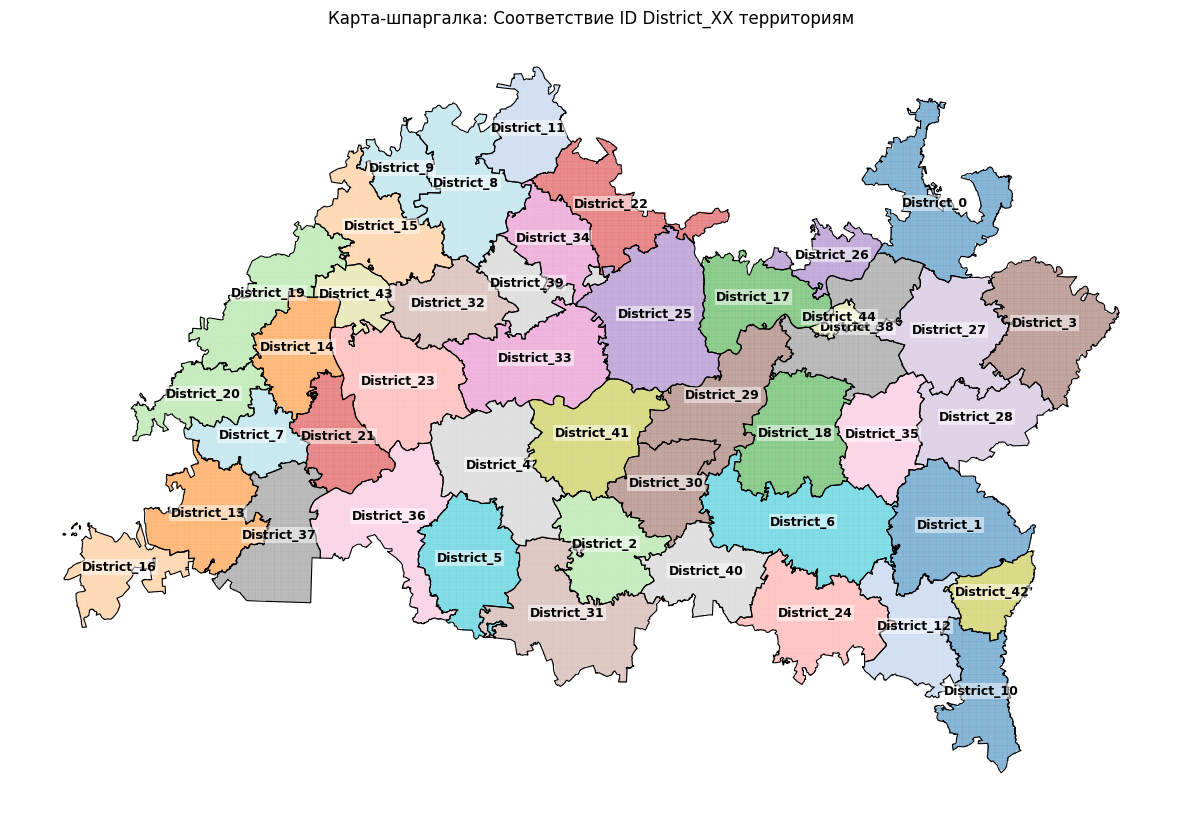

In [11]:
# 1. Рисуем базовую карту (как у тебя была)
fig, ax = plt.subplots(figsize=(15, 12))
grid_with_districts.plot(ax=ax, column='name', cmap='tab20', edgecolors='white', linewidth=0.1, alpha=0.6)
districts.boundary.plot(ax=ax, color='black', linewidth=0.8)

# 2. ДОБАВЛЯЕМ ПОДПИСИ ID В ЦЕНТРЕ КАЖДОГО РАЙОНА
for idx, row in districts.iterrows():
    # Вычисляем центр района для подписи
    centroid = row.geometry.centroid
    # Рисуем текст (имя из колонки 'name', где лежат District_XX)
    ax.text(centroid.x, centroid.y, str(row['name']), 
            fontsize=9, fontweight='bold', ha='center', 
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))

plt.title("Карта-шпаргалка: Соответствие ID District_XX территориям")
plt.axis('off')
plt.show()


In [12]:
# 1. ПОДГОТОВКА СЛОВАРЯ (Связываем ID и Русское название)
# Используем твой ручной маппинг, это надежнее всего
district_names = {
    'District_0': 'Агрызский район', 'District_1': 'Азнакаевский район', 
    'District_2': 'Аксубаевский район', 'District_3': 'Актанышский район',
    'District_4': 'Алексеевский район', 'District_5': 'Алькеевский район',
    'District_6': 'Альметьевский район', 'District_7': 'Апастовский район',
    'District_8': 'Арский район', 'District_9': 'Атнинский район',
    'District_10': 'Бавлинский район', 'District_11': 'Балтасинский район',
    'District_12': 'Бугульминский район', 'District_13': 'Буинский район',
    'District_14': 'Верхнеуслонский район', 'District_15': 'Высокогорский район',
    'District_16': 'Дрожжановский район', 'District_17': 'Елабужский район',
    'District_18': 'Заинский район', 'District_19': 'Зеленодольский район',
    'District_20': 'Кайбицкий район', 'District_21': 'Камско-Устьинский район',
    'District_22': 'Кукморский район', 'District_23': 'Лаишевский район',
    'District_24': 'Лениногорский район', 'District_25': 'Мамадышский район',
    'District_26': 'Менделеевский район', 'District_27': 'Мензелинский район',
    'District_28': 'Муслюмовский район', 'District_29': 'Нижнекамский район',
    'District_30': 'Новошешминский район', 'District_31': 'Нурлатский район',
    'District_32': 'Пестречинский район', 'District_33': 'Рыбно-Слободский район',
    'District_34': 'Сабинский район', 'District_35': 'Сармановский район',
    'District_36': 'Спасский район', 'District_37': 'Тетюшский район',
    'District_38': 'Тукаевский район', 'District_39': 'Тюлячинский район',
    'District_40': 'Черемшанский район', 'District_41': 'Чистопольский район',
    'District_42': 'Ютазинский район', 
    'District_43': 'г. Казань', 
    'District_44': 'г. Набережные Челны'
}

# 2. СОЗДАНИЕ МАСТЕР-ТАБЛИЦЫ ИЗ СЕТКИ
# Переводим в WGS84 (градусы), чтобы получить Lat/Lon для координат
grid_wgs84 = grid_with_districts.to_crs(epsg=4326)

master_table = pd.DataFrame({
    'district_id': grid_with_districts['name'],
    'district_name': grid_with_districts['name'].map(district_names),
    'lon': grid_wgs84.geometry.centroid.x,
    'lat': grid_wgs84.geometry.centroid.y
})

# 3. ДОБАВЛЯЕМ ГЕОМЕТРИЮ (в метрах, для расчетов) И ПРИЗНАКИ
# Если у тебя в grid_with_districts уже были свет и дороги, подтянем их
for col in ['light_final', 'road_len', 'rail_len']:
    if col in grid_with_districts.columns:
        master_table[col] = grid_with_districts[col]
    else:
        master_table[col] = 0.0 # Заглушка, если еще не посчитано

# 4. ПРОВЕРКА
print("Мастер-таблица готова!")
print(f"Всего ячеек: {len(master_table)}")
print(f"Районов привязано: {master_table['district_name'].nunique()} из 45")
print("\nПервые строки:")
print(master_table.head())

# Сохраняем, чтобы не потерять
master_table.to_csv('master_grid_tatarstan.csv', index=False)


C:\Users\Тихон\AppData\Local\Temp\ipykernel_11852\1667593727.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  'lon': grid_wgs84.geometry.centroid.x,
C:\Users\Тихон\AppData\Local\Temp\ipykernel_11852\1667593727.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  'lat': grid_wgs84.geometry.centroid.y


Мастер-таблица готова!
Всего ячеек: 67986
Районов привязано: 45 из 45

Первые строки:
   district_id        district_name        lon        lat  light_final  \
0  District_16  Дрожжановский район  47.275598  54.681804          0.0   
1  District_16  Дрожжановский район  47.274776  54.690771          0.0   
2  District_16  Дрожжановский район  47.291076  54.682279          0.0   
3  District_16  Дрожжановский район  47.290257  54.691247          0.0   
4  District_16  Дрожжановский район  47.289438  54.700215          0.0   

   road_len  rail_len  
0       0.0       0.0  
1       0.0       0.0  
2       0.0       0.0  
3       0.0       0.0  
4       0.0       0.0  


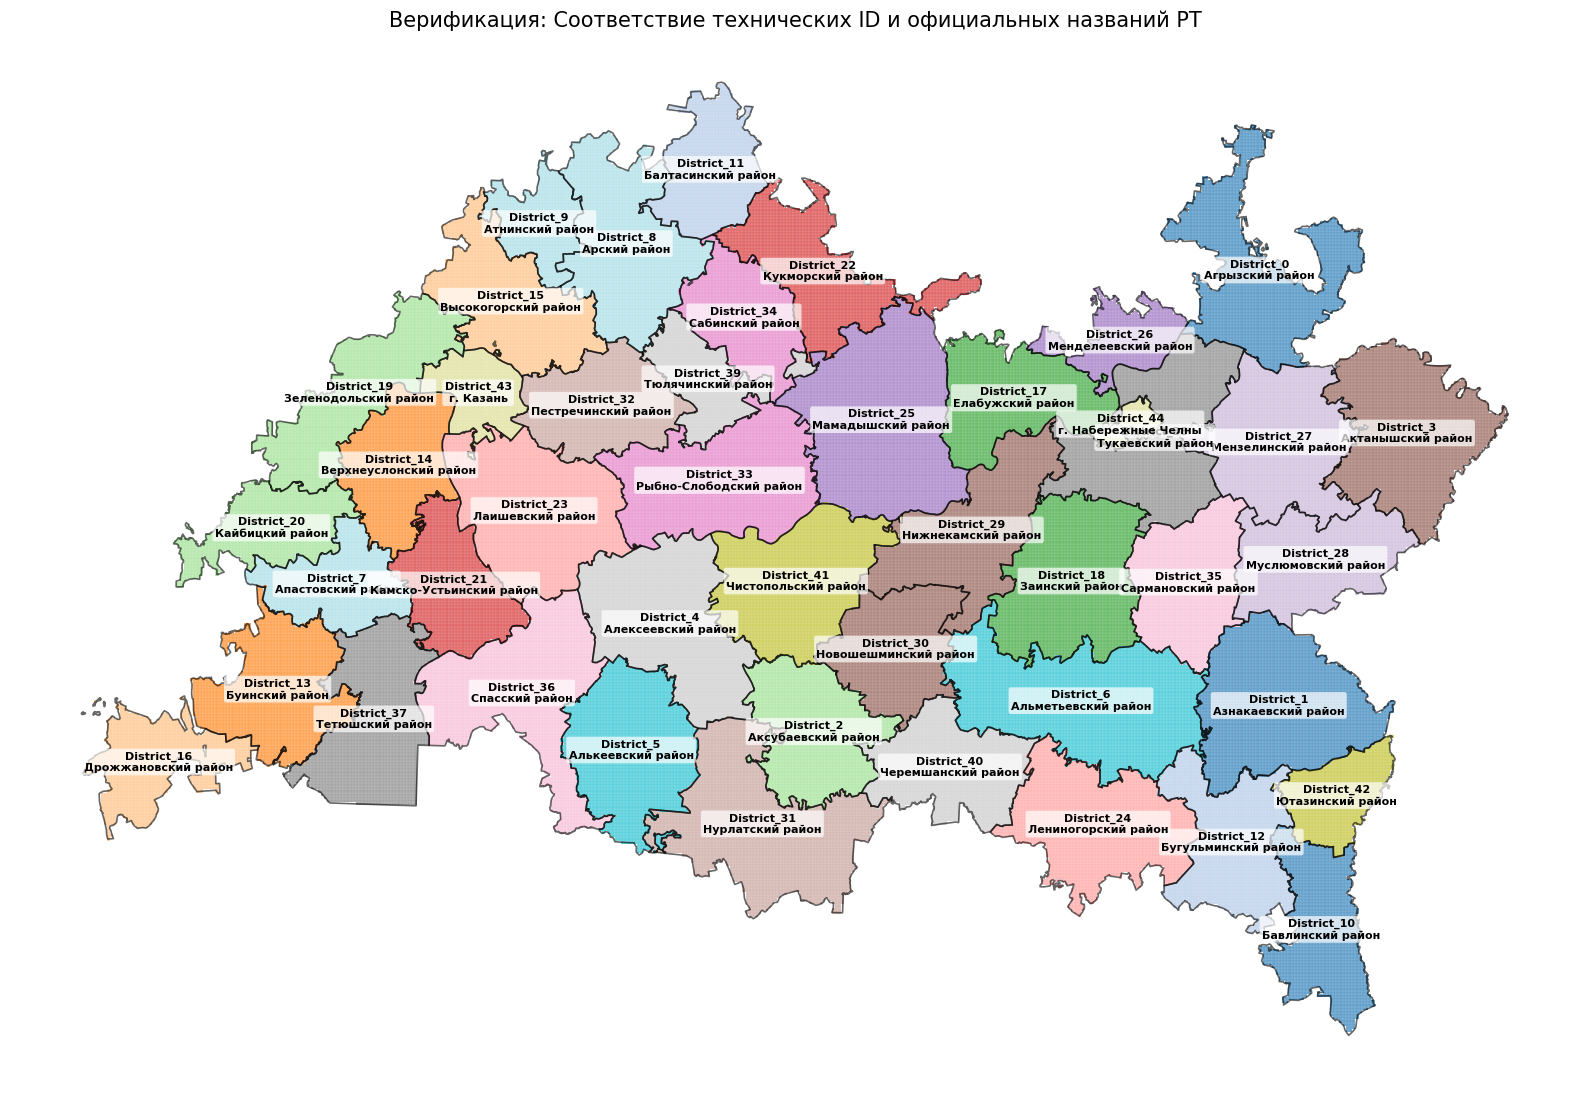

--- Список для финальной сверки (первые 10) ---
District_0 ===> Агрызский район
District_1 ===> Азнакаевский район
District_2 ===> Аксубаевский район
District_3 ===> Актанышский район
District_4 ===> Алексеевский район
District_5 ===> Алькеевский район
District_6 ===> Альметьевский район
District_7 ===> Апастовский район
District_8 ===> Арский район
District_9 ===> Атнинский район


In [13]:
# 1. Создаем временный слой для отрисовки подписей
# Используем центроиды районов для размещения текста
districts_labels = districts.copy()
districts_labels['centroid'] = districts_labels.geometry.centroid

# 2. Настраиваем словарь (убедись, что manual_mapping из прошлых шагов под рукой)
# Если словаря нет в памяти, он создастся здесь
labels_dict = district_names # тот самый словарь с 45 именами

# 3. ВИЗУАЛИЗАЦИЯ
fig, ax = plt.subplots(figsize=(16, 12))

# Рисуем саму сетку, раскрашенную по районам
grid_with_districts.plot(ax=ax, column='name', cmap='tab20', 
                         edgecolor='white', linewidth=0.1, alpha=0.7)

# Рисуем жирные границы районов
districts.boundary.plot(ax=ax, color='black', linewidth=1.2, alpha=0.6)

# Добавляем текстовые блоки: "District_X \n Название"
for idx, row in districts_labels.iterrows():
    d_id = row['name'] # Это District_XX
    d_rus = labels_dict.get(d_id, "???") # Это Русское название
    
    # Координаты центра
    x, y = row['centroid'].x, row['centroid'].y
    
    # Сама подпись с белой подложкой для читаемости
    ax.text(x, y, f"{d_id}\n{d_rus}", 
            fontsize=8, fontweight='bold', ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

plt.title("Верификация: Соответствие технических ID и официальных названий РТ", fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.show()

# 4. КОНТРОЛЬНАЯ ПРОВЕРКА В ТЕКСТЕ
print("--- Список для финальной сверки (первые 10) ---")
for i in range(10):
    d_id = f"District_{i}"
    print(f"{d_id} ===> {labels_dict.get(d_id)}")


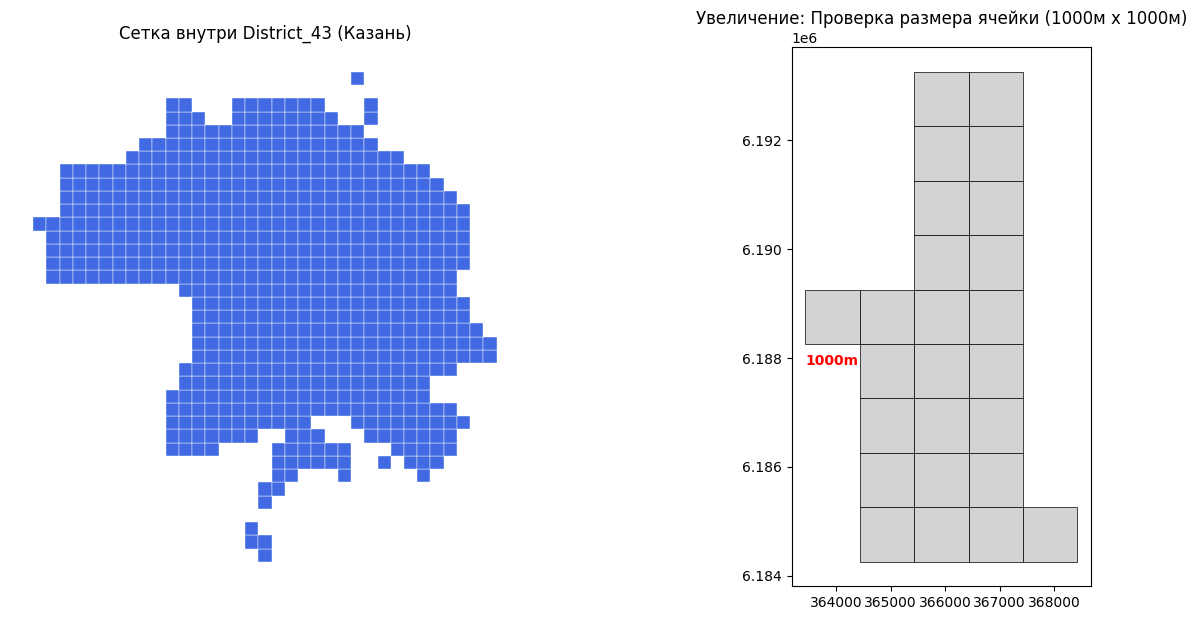

--- ТЕХНИЧЕСКАЯ ВЕРИФИКАЦИЯ ---
Ширина ячейки: 1000 метров
Высота ячейки: 1000 метров
Площадь ячейки: 1.0 кв. км
Всего ячеек в Татарстане: 67986


In [14]:
# 1. Выбираем один район для детальной проверки (например, District_43 - Казань)
check_district = 'District_43'
subset = grid_with_districts[grid_with_districts['name'] == check_district]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ГРАФИК 1: Район целиком
subset.plot(ax=ax1, edgecolor='white', linewidth=0.3, color='royalblue')
ax1.set_title(f"Сетка внутри {check_district} (Казань)")
ax1.axis('off')

# ГРАФИК 2: Зум на ячейки (берем первые 25 ячеек из таблицы)
# Рисуем сетку с подписями координат, чтобы проверить шаг в 1000 метров
zoom_subset = subset.head(25)
zoom_subset.plot(ax=ax2, edgecolor='black', linewidth=0.5, color='lightgrey')

# Добавим подписи координат для одной ячейки, чтобы подтвердить 1 км
for idx, row in zoom_subset.head(1).iterrows():
    minx, miny, maxx, maxy = row.geometry.bounds
    ax2.annotate(f'{int(maxx-minx)}m', xy=(minx + 500, miny), xytext=(0, -15), 
                 textcoords='offset points', ha='center', fontweight='bold', color='red')

ax2.set_title("Увеличение: Проверка размера ячейки (1000м x 1000м)")
plt.show()

# ТЕХНИЧЕСКИЙ ВЫВОД
sample_cell = grid_with_districts.geometry.iloc[0]
minx, miny, maxx, maxy = sample_cell.bounds
print(f"--- ТЕХНИЧЕСКАЯ ВЕРИФИКАЦИЯ ---")
print(f"Ширина ячейки: {maxx - minx:.0f} метров")
print(f"Высота ячейки: {maxy - miny:.0f} метров")
print(f"Площадь ячейки: {(maxx - minx) * (maxy - miny) / 1000000:.1f} кв. км")
print(f"Всего ячеек в Татарстане: {len(grid_with_districts)}")


# Внедряем засветку

Привязываю засветку к ячейкам...


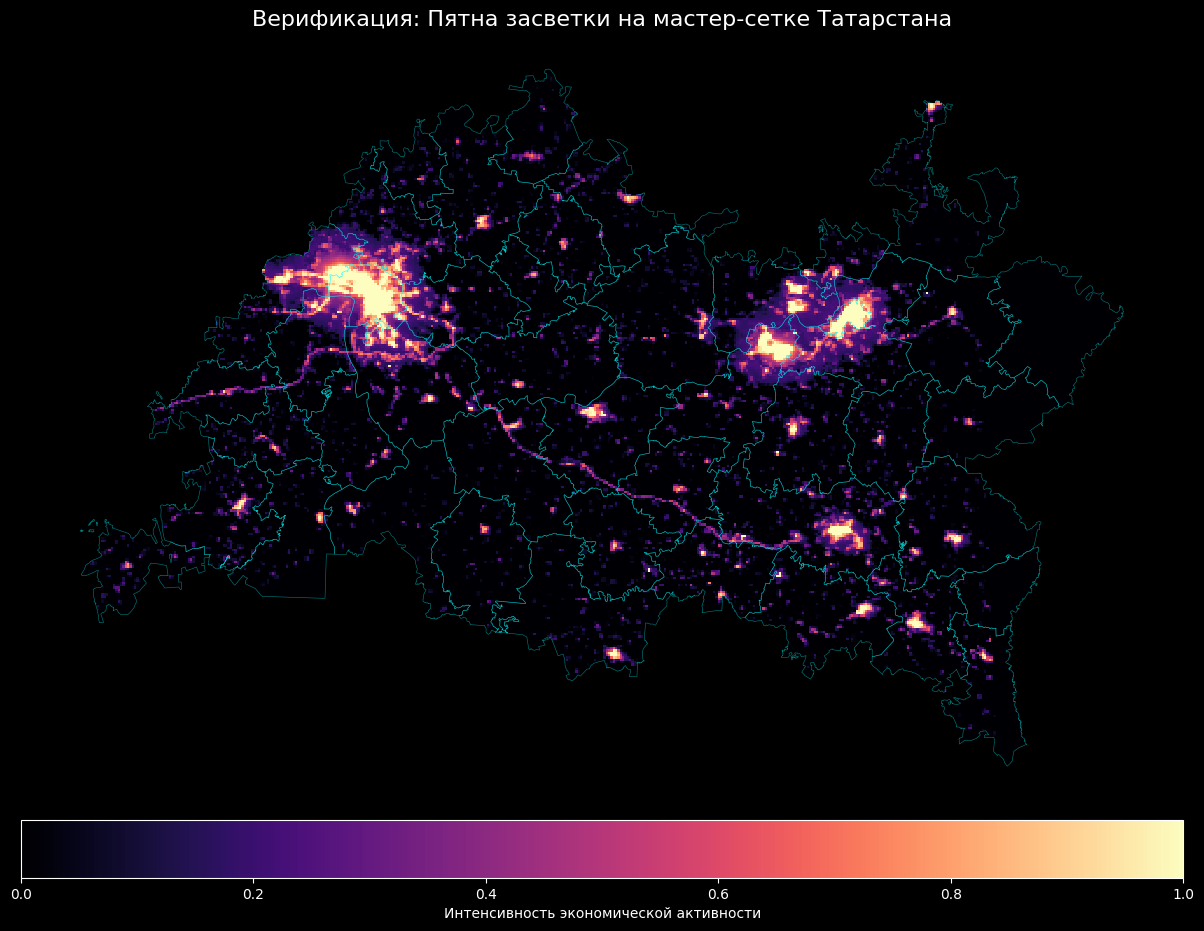

Готово! Ячеек с активностью: 16272


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from rasterstats import zonal_stats

# 1. ПОВТОРНЫЙ РАСЧЕТ И ПРАВИЛЬНАЯ ПРИВЯЗКА
# Используем grid_with_districts, где уже есть привязанные названия районов
raster_path = 'viirs_npp_202500.tif' 
grid_4326 = grid_with_districts.to_crs(epsg=4326)

print("Привязываю засветку к ячейкам...")
# Используем mean для стабильности или max для более резких пятен
stats = zonal_stats(grid_4326, raster_path, stats="mean")
grid_with_districts['light'] = [x['mean'] if x['mean'] is not None else 0 for x in stats]

# 2. "ЛЕЧЕНИЕ" ДАННЫХ (Твой проверенный алгоритм)
limit = grid_with_districts['light'].quantile(0.99)
grid_with_districts['light_clipped'] = grid_with_districts['light'].clip(upper=limit)
grid_with_districts['light_log'] = np.log1p(grid_with_districts['light_clipped'])

max_val = grid_with_districts['light_log'].max()
grid_with_districts['light_final'] = grid_with_districts['light_log'] / max_val if max_val > 0 else 0

# 3. ВИЗУАЛИЗАЦИЯ "ТЕХ САМЫХ ПЯТЕН"
plt.style.use('dark_background') # Черный фон для эффекта космоса
fig, ax = plt.subplots(figsize=(15, 12))

# Отрисовка: linewidth=0 и antialiased=False убирают сетку, делая пятна литыми
grid_with_districts.plot(
    ax=ax, 
    column='light_final', 
    cmap='magma',     # 'magma' или 'inferno' дают лучший эффект свечения
    linewidth=0, 
    antialiased=False,
    legend=True,
    legend_kwds={'label': "Интенсивность экономической активности", 'orientation': "horizontal", 'pad': 0.02}
)

# Тонкие границы районов (голубой неон, как на твоем референсе)
districts.to_crs(grid_with_districts.crs).boundary.plot(
    ax=ax, color='cyan', linewidth=0.4, alpha=0.5
)

plt.title("Верификация: Пятна засветки на мастер-сетке Татарстана", fontsize=16, color='white')
ax.axis('off')
plt.show()
plt.style.use('default')

print(f"Готово! Ячеек с активностью: {(grid_with_districts['light_final'] > 0).sum()}")


In [16]:
grid_with_districts.head()

,geometry,name,light,light_clipped,light_log,light_final
0,"POLYGON ((259429.845 6065254.132, 260429.845 6...",District_16,0.0,0.0,0.0,0.0
1,"POLYGON ((259429.845 6066254.132, 260429.845 6...",District_16,0.0,0.0,0.0,0.0
2,"POLYGON ((260429.845 6065254.132, 261429.845 6...",District_16,0.0,0.0,0.0,0.0
3,"POLYGON ((260429.845 6066254.132, 261429.845 6...",District_16,0.0,0.0,0.0,0.0
4,"POLYGON ((260429.845 6067254.132, 261429.845 6...",District_16,0.0,0.0,0.0,0.0


# Внедряем дороги

In [17]:
# 1. ПОДГОТОВКА ГРАНИЦЫ
temp_districts = districts.to_crs(epsg=4326)
poly_boundary = temp_districts.unary_union

print("Загружаю дороги из OSM... (это может занять время)")
roads = ox.features_from_polygon(poly_boundary, tags={'highway': ['motorway', 'trunk', 'primary', 'secondary', 'tertiary']})
rails = ox.features_from_polygon(poly_boundary, tags={'railway': 'rail'})

# 2. ПРИВЕДЕНИЕ К МЕТРАМ
roads = roads.to_crs(epsg=32639)
rails = rails.to_crs(epsg=32639)
roads = roads[roads.geometry.type.isin(['LineString', 'MultiLineString'])]
rails = rails[rails.geometry.type.isin(['LineString', 'MultiLineString'])]

# 3. ПОДГОТОВКА СЕТКИ ДЛЯ ГЕО-ОПЕРАЦИЙ
# Создаем временный ID для корректной группировки после overlay
grid_with_districts['temp_id'] = grid_with_districts.index
grid_geom = grid_with_districts[['temp_id', 'geometry']].copy()

print("Считаю пересечения дорог с сеткой...")
# Используем 'temp_id' для связи результатов overlay с основной таблицей
roads_clipped = gpd.overlay(roads[['geometry']], grid_geom, how='intersection')
roads_clipped['length'] = roads_clipped.geometry.length
road_lengths = roads_clipped.groupby('temp_id')['length'].sum()

print("Считаю ж/д...")
rails_clipped = gpd.overlay(rails[['geometry']], grid_geom, how='intersection')
rails_clipped['length'] = rails_clipped.geometry.length
rail_lengths = rails_clipped.groupby('temp_id')['length'].sum()

# 4. ЗАПИСЬ В ТАБЛИЦУ
grid_with_districts['road_len'] = grid_with_districts['temp_id'].map(road_lengths).fillna(0)
grid_with_districts['rail_len'] = grid_with_districts['temp_id'].map(rail_lengths).fillna(0)

# Удаляем временную колонку
grid_with_districts = grid_with_districts.drop(columns=['temp_id'])

print("✅ Транспортные признаки синхронизированы с Master-Table!")
print(grid_with_districts[['name', 'light_final', 'road_len', 'rail_len']].head())


C:\Users\Тихон\AppData\Local\Temp\ipykernel_11852\3109929862.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly_boundary = temp_districts.unary_union


Загружаю дороги из OSM... (это может занять время)


C:\Users\Тихон\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 38 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)
C:\Users\Тихон\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 38 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Считаю пересечения дорог с сеткой...
Считаю ж/д...
✅ Транспортные признаки синхронизированы с Master-Table!
          name  light_final  road_len  rail_len
0  District_16          0.0       0.0       0.0
1  District_16          0.0       0.0       0.0
2  District_16          0.0       0.0       0.0
3  District_16          0.0       0.0       0.0
4  District_16          0.0       0.0       0.0


Отрисовка дорог...
Отрисовка ж/д...


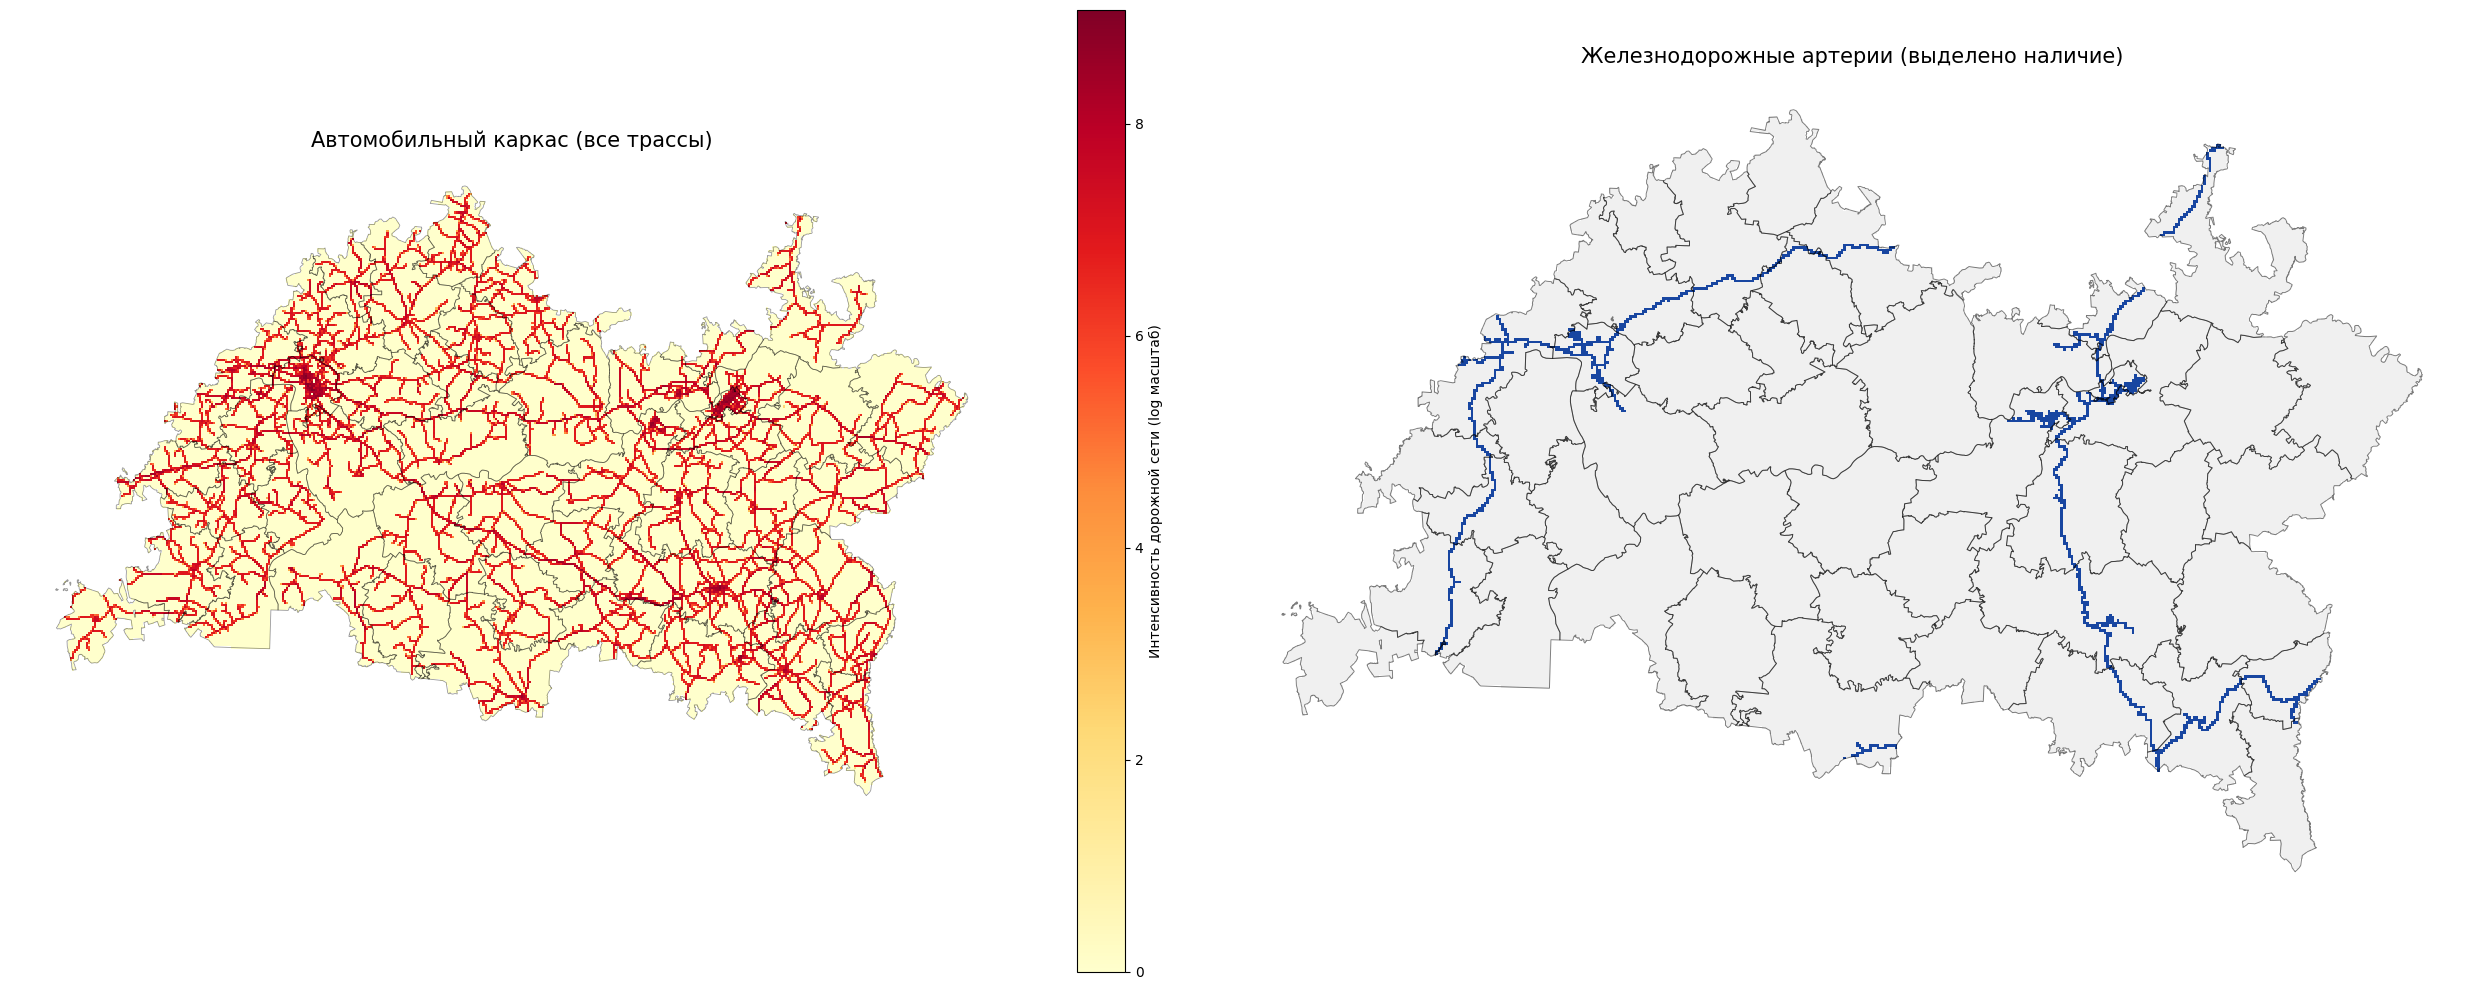

Сохраняю Мастер-таблицу...
Успешно! Все признаки (свет, дороги, жд) собраны в одном файле.


In [18]:
# Создаем полотно с двумя графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 10))

# --- 1. КАРТА АВТОДОРОГ (с логарифмическим усилением) ---
print("Отрисовка дорог...")
# Используем road_len, который мы только что посчитали через overlay
grid_with_districts['road_log'] = np.log1p(grid_with_districts['road_len'])

grid_with_districts.plot(ax=ax1, column='road_log', cmap='YlOrRd', 
                         legend=True, 
                         legend_kwds={'label': "Интенсивность дорожной сети (log масштаб)"})

# Используем districts.to_crs, чтобы границы районов точно совпали с сеткой
districts.to_crs(grid_with_districts.crs).boundary.plot(ax=ax1, color='black', linewidth=0.6, alpha=0.4)
ax1.set_title("Автомобильный каркас (все трассы)", fontsize=15)
ax1.axis('off')

# --- 2. КАРТА ЖЕЛЕЗНЫХ ДОРОГ (Акцентированная) ---
print("Отрисовка ж/д...")
# Рисуем подложку (светло-серый фон для всех ячеек)
grid_with_districts.plot(ax=ax2, color='#f0f0f0', edgecolor='none')

# Накладываем только те ячейки, где есть ж/д (rail_len > 0)
rails_exist = grid_with_districts[grid_with_districts['rail_len'] > 0]
if not rails_exist.empty:
    rails_exist.plot(ax=ax2, color='#003399', alpha=0.9)

# Границы районов
districts.to_crs(grid_with_districts.crs).boundary.plot(ax=ax2, color='black', linewidth=0.7, alpha=0.5)

ax2.set_title("Железнодорожные артерии (выделено наличие)", fontsize=15)
ax2.axis('off')

plt.tight_layout()
plt.show()

# --- СОХРАНЕНИЕ ---
print("Сохраняю Мастер-таблицу...")
# Сохраняем в GeoJSON для ГИС или в CSV для простых расчетов в Excel
grid_with_districts.to_file("tatarstan_master_grid_FINAL.geojson", driver='GeoJSON')
print("Успешно! Все признаки (свет, дороги, жд) собраны в одном файле.")


# Расчет инвестиций по ячейкам 1*1 км

In [21]:
# 0. ВОССТАНАВЛИВАЕМ ДАННЫЕ ИЗ EXCEL
# Укажи здесь точное имя своего файла
excel_file = 'invest_2025.xlsx' 

if 'df_invest' not in locals():
    print(f"Загружаю {excel_file}...")
    df_invest = pd.read_excel(excel_file)
    # Чистим числа от пробелов на всякий случай
    df_invest['investment'] = pd.to_numeric(df_invest['investment'].astype(str).str.replace(r'\s+', '', regex=True), errors='coerce').fillna(0)

# 1. ПРИВЯЗЫВАЕМ ДЕНЬГИ К СЕТКЕ
# Проверяем, нет ли уже колонки 'investment', чтобы не дублировать
if 'investment' not in grid_with_districts.columns:
    print("Привязываю инвестиции к районам на сетке...")
    grid_with_districts = grid_with_districts.merge(
        df_invest[['district_id', 'investment']], 
        left_on='name', 
        right_on='district_id', 
        how='left'
    )

# 2. НОРМАЛИЗАЦИЯ ТРАНСПОРТА
grid_with_districts['road_n'] = grid_with_districts['road_len'] / grid_with_districts['road_len'].max() if grid_with_districts['road_len'].max() > 0 else 0
grid_with_districts['rail_n'] = grid_with_districts['rail_len'] / grid_with_districts['rail_len'].max() if grid_with_districts['rail_len'].max() > 0 else 0

# 3. ИТОГОВЫЙ ВЕС (40/40/20)
grid_with_districts['total_w'] = (grid_with_districts['light_final'] * 0.4) + \
                                 (grid_with_districts['road_n'] * 0.4) + \
                                 (grid_with_districts['rail_n'] * 0.2)

# Заплатка для пустых зон
grid_with_districts['total_w'] = grid_with_districts['total_w'].replace(0, 0.0001)

# 4. РАСПРЕДЕЛЕНИЕ
dist_weight_sum = grid_with_districts.groupby('name')['total_w'].transform('sum')
grid_with_districts['invest_cell'] = grid_with_districts['investment'] * (grid_with_districts['total_w'] / dist_weight_sum)

# 5. ВЕРИФИКАЦИЯ
total_excel = df_invest['investment'].sum()
total_grid = grid_with_districts['invest_cell'].sum()

print("-" * 30)
print(f"СУММА ПО EXCEL: {total_excel:,.2f} руб.")
print(f"СУММА ПО СЕТКЕ: {total_grid:,.2f} руб.")
print(f"ТОЧНОСТЬ: {(total_grid / total_excel)*100:.6f}%")
print("-" * 30)


Загружаю invest_2025.xlsx...
Привязываю инвестиции к районам на сетке...
------------------------------
СУММА ПО EXCEL: 1,483,321,593.00 руб.
СУММА ПО СЕТКЕ: 1,483,321,593.00 руб.
ТОЧНОСТЬ: 100.000000%
------------------------------


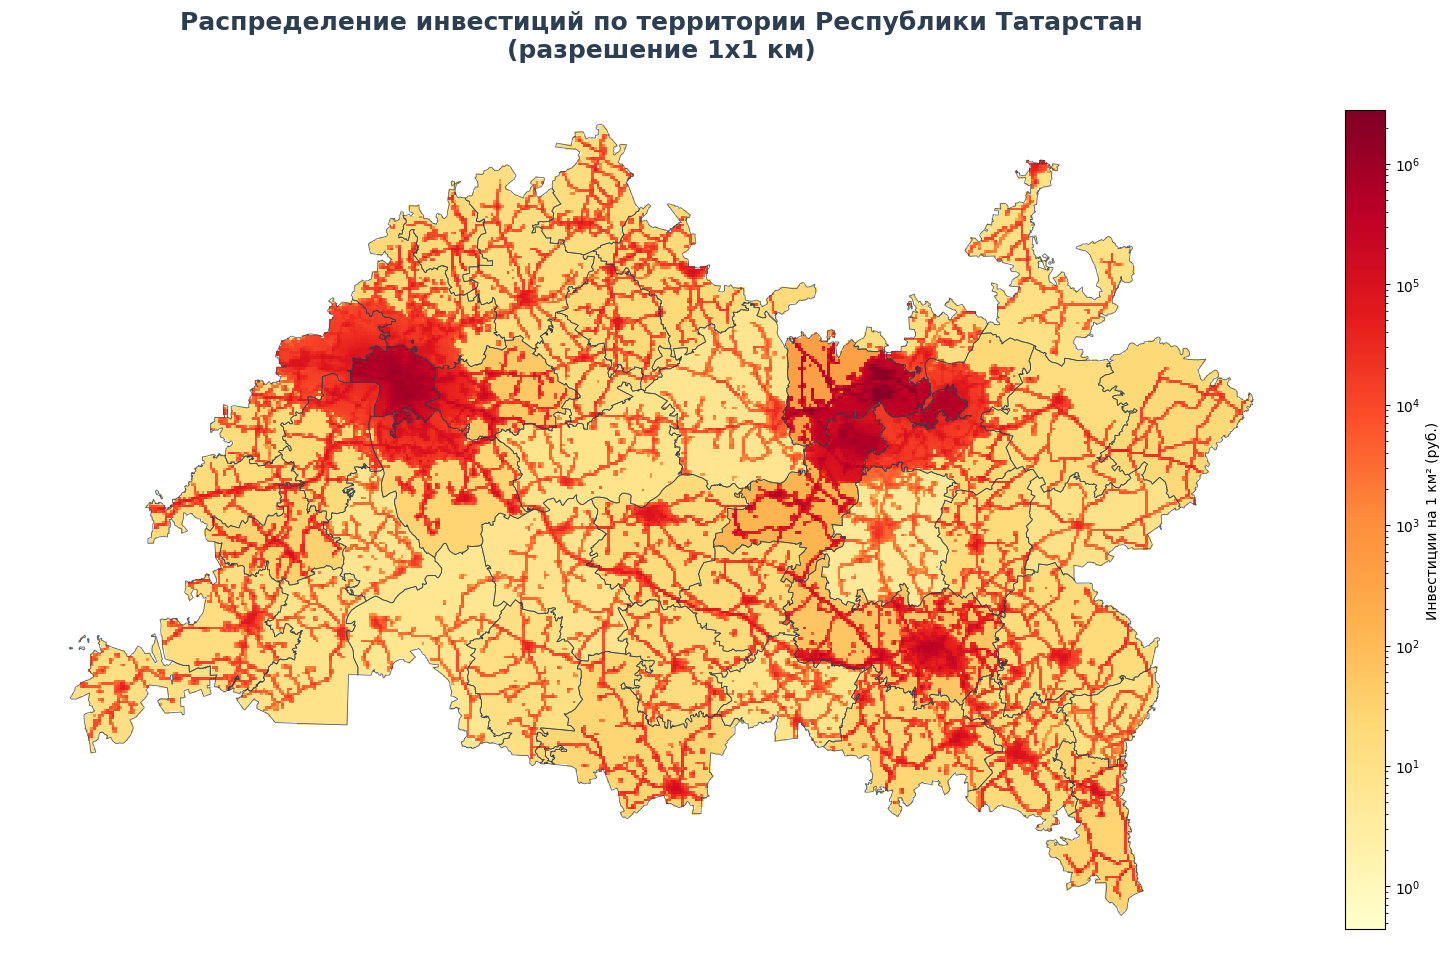

In [24]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Возвращаемся к светлому стилю
plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 12), facecolor='white')

# 1. Настройка цветовой шкалы (логарифмическая для контраста)
v_min = grid_with_districts[grid_with_districts['invest_cell'] > 0]['invest_cell'].min()
v_max = grid_with_districts['invest_cell'].max()

# 2. Отрисовка инвестиций
# Палитра 'YlOrRd' (Yellow-Orange-Red) — классика для экономики
grid_with_districts.plot(
    ax=ax, 
    column='invest_cell', 
    cmap='YlOrRd', 
    norm=colors.LogNorm(vmin=v_min, vmax=v_max),
    linewidth=0, 
    antialiased=False,
    legend=True,
    legend_kwds={
        'label': "Инвестиции на 1 км² (руб.)", 
        'orientation': "vertical", 
        'shrink': 0.7,
        'pad': 0.02
    }
)

# 3. Границы районов (темно-серый или синий для строгости)
districts.to_crs(grid_with_districts.crs).boundary.plot(
    ax=ax, 
    color='#2c3e50', # Глубокий темно-синий/серый
    linewidth=0.6, 
    alpha=0.8
)

# 4. Оформление
plt.title("Распределение инвестиций по территории Республики Татарстан\n(разрешение 1х1 км)", 
          fontsize=18, fontweight='bold', color='#2c3e50', pad=20)

# Убираем оси, но оставляем белый фон
ax.axis('off')

# Можно добавить фоновую сетку координат (очень бледно), если нужно для солидности
ax.grid(color='grey', linestyle='--', linewidth=0.2, alpha=0.5)

plt.tight_layout()
plt.show()


In [25]:
# Выбираем два района для сверки
test_districts = {
    'District_43': 'Казань',
    'District_25': 'Мамадышский'
}

print(f"{'Район':<20} | {'Сумма Excel (руб.)':<20} | {'Сумма Сетка (руб.)':<20} | {'Дельта':<10}")
print("-" * 75)

for d_id, d_name in test_districts.items():
    # Сумма из исходного Excel (находим по district_id)
    excel_val = df_invest[df_invest['district_id'] == d_id]['investment'].values[0]
    
    # Сумма всех ячеек этого района в нашей финальной сетке
    grid_sum = grid_with_districts[grid_with_districts['name'] == d_id]['invest_cell'].sum()
    
    delta = excel_val - grid_sum
    
    print(f"{d_name:<20} | {excel_val:>20,.2f} | {grid_sum:>20,.2f} | {delta:>10.2f}")

# Дополнительно: посмотрим на "самую дорогую" ячейку в Казани
top_cell = grid_with_districts[grid_with_districts['name'] == 'District_43']['invest_cell'].max()
print(f"\nПиковая инвестиция в одной ячейке Казани: {top_cell:,.2f} руб.")


Район                | Сумма Excel (руб.)   | Сумма Сетка (руб.)   | Дельта    
---------------------------------------------------------------------------
Казань               |       332,940,763.00 |       332,940,763.00 |       0.00
Мамадышский          |         3,288,165.00 |         3,288,165.00 |      -0.00

Пиковая инвестиция в одной ячейке Казани: 1,110,027.36 руб.
